## Loading Data and Inspecting

In [1]:
import pandas as pd
import os

In [2]:
os.getcwd()

'/content'

In [5]:
df = pd.read_csv('nvidia.csv')

# ===================== EDA START =====================

In [6]:
# EDA Section

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
         Date       Open       High        Low      Close  Adj Close    Volume
0  2019-05-23  37.422501  37.422501  36.227501  36.830002  36.579872  59184400
1  2019-05-24  37.020000  37.375000  36.220001  36.287498  36.041054  35758400
2  2019-05-28  36.465000  36.794998  35.812500  35.832500  35.589134  42835600
3  2019-05-29  35.352501  35.705002  34.735001  35.084999  34.846722  55980000
4  2019-05-30  35.077499  35.437500  34.392502  34.777500  34.580738  39430000

Shape of dataset:
(1260, 7)

Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1260 non-null   object 
 1   Open       1260 non-null   float64
 2   High       1260 non-null   float64
 3   Low        1260 non-null   float64
 4   Close      1260 non-

In [7]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

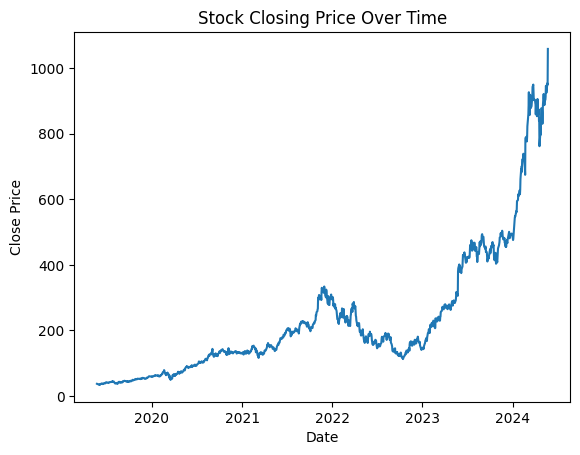

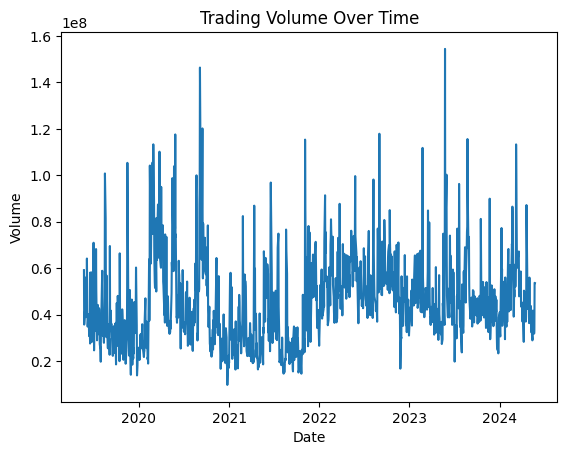

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Closing Price Trend
plt.figure()
plt.plot(df['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

# Volume Trend
plt.figure()
plt.plot(df['Volume'])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

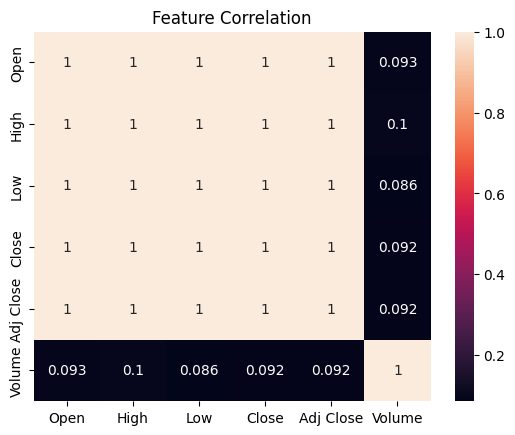

In [9]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

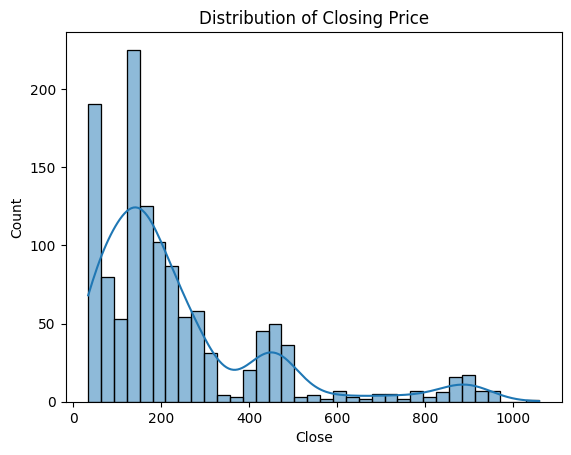

In [10]:
sns.histplot(df['Close'], kde=True)
plt.title("Distribution of Closing Price")
plt.show()

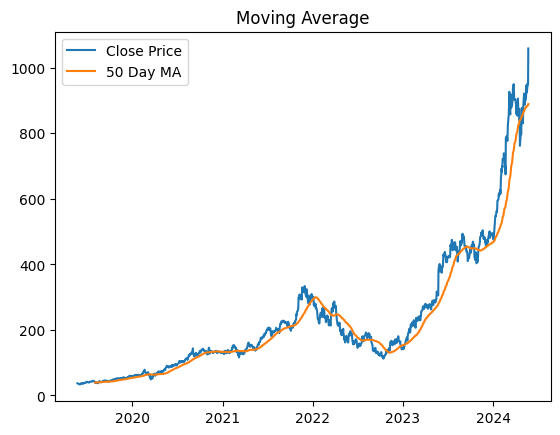

In [11]:
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure()
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA50'], label='50 Day MA')
plt.legend()
plt.title("Moving Average")
plt.show()

In [12]:
df = df.reset_index()

In [13]:
print(df.head())
print(df.info())
print(df.isnull().sum())

        Date       Open       High        Low      Close  Adj Close    Volume  \
0 2019-05-23  37.422501  37.422501  36.227501  36.830002  36.579872  59184400   
1 2019-05-24  37.020000  37.375000  36.220001  36.287498  36.041054  35758400   
2 2019-05-28  36.465000  36.794998  35.812500  35.832500  35.589134  42835600   
3 2019-05-29  35.352501  35.705002  34.735001  35.084999  34.846722  55980000   
4 2019-05-30  35.077499  35.437500  34.392502  34.777500  34.580738  39430000   

   MA50  
0   NaN  
1   NaN  
2   NaN  
3   NaN  
4   NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1260 non-null   datetime64[ns]
 1   Open       1260 non-null   float64       
 2   High       1260 non-null   float64       
 3   Low        1260 non-null   float64       
 4   Close      1260 non-null   float64       
 5   Adj Close  12

## Convert Data and sort

In [14]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()

In [15]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA50
Date,,,,,,,
2019-05-23,37.422501,37.422501,36.227501,36.830002,36.579872,59184400,NaN
2019-05-24,37.020000,37.375000,36.220001,36.287498,36.041054,35758400,NaN
2019-05-28,36.465000,36.794998,35.812500,35.832500,35.589134,42835600,NaN
2019-05-29,35.352501,35.705002,34.735001,35.084999,34.846722,55980000,NaN
2019-05-30,35.077499,35.437500,34.392502,34.777500,34.580738,39430000,NaN


## Handling Missing Values

In [16]:
df.ffill(inplace=True)

In [17]:
df.head

<bound method NDFrame.head of                    Open         High          Low        Close    Adj Close  \
Date                                                                          
2019-05-23    37.422501    37.422501    36.227501    36.830002    36.579872   
2019-05-24    37.020000    37.375000    36.220001    36.287498    36.041054   
2019-05-28    36.465000    36.794998    35.812500    35.832500    35.589134   
2019-05-29    35.352501    35.705002    34.735001    35.084999    34.846722   
2019-05-30    35.077499    35.437500    34.392502    34.777500    34.580738   
...                 ...          ...          ...          ...          ...   
2024-05-17   943.690002   947.400024   918.059998   924.789978   924.789978   
2024-05-20   937.500000   952.000000   934.400024   947.799988   947.799988   
2024-05-21   935.989990   954.000000   931.799988   953.859985   953.859985   
2024-05-22   954.590027   960.200012   932.489990   949.500000   949.500000   
2024-05-23  1020.000000  1063.199951  1015.200012  1058.918579  1058.918579   

              Volume        MA50  
Date                              
2019-05-23  59184400         NaN  
2019-05-24  35758400         NaN  
2019-05-28  42835600         NaN  
2019-05-29  55980000         NaN  
2019-05-30  39430000         NaN  
...              ...         ...  
2024-05-17  35969100  882.417799  
2024-05-20  31876400  883.868198  
2024-05-21  32894600  885.790598  
2024-05-22  53725900  886.397998  
2024-05-23  53658481  889.398770  

[1260 rows x 7 columns]>

## FeatureEngineering

In [18]:

df['MA10'] = df['Close'].rolling(window = 10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

In [19]:
df['Return'] = df['Close'].pct_change()
df["Target"] = df["Return"].shift(-1)

In [20]:
df['volatility'] = df['Return'].rolling(window=10).std()

In [21]:
df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)

## Defining the targeting variable


In [22]:
df = df.dropna()
x = df.drop(columns=["Target"])
y = df["Target"]

In [23]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA50,MA10,Return,Target,volatility,Lag1,Lag2,Lag3
Date,,,,,,,,,,,,,,
2019-08-02,40.297501,40.994999,39.820000,40.297501,40.069515,42834800,39.32900,42.979751,-0.022617,-0.064520,0.022426,41.230000,42.180000,43.862499
2019-08-05,38.450001,38.462502,37.224998,37.697498,37.484203,58915600,39.34635,42.466500,-0.064520,0.010346,0.027990,40.297501,41.230000,42.180000
2019-08-06,38.450001,38.907501,37.607498,38.087502,37.872009,36127200,39.38235,41.883751,0.010346,0.010108,0.026087,37.697498,40.297501,41.230000
2019-08-07,37.474998,38.592499,37.299999,38.472500,38.254829,37256000,39.43515,41.264500,0.010108,0.028397,0.025249,38.087502,37.697498,40.297501
2019-08-08,39.052502,39.577499,38.474998,39.564999,39.341145,30930000,39.52475,40.886500,0.028397,-0.025780,0.027923,38.472500,38.087502,37.697498


In [25]:
df.to_csv("processed_nvidia.csv")